# Seoul Bikes Linear Regression By hand
### Evan André Santana Pacheco A01769493
### TC3009C.601

Predictive Modeling of Urban Bike-Sharing Demand in Seoul
Seoul Bike Sharing Demand (UCI Machine Learning Repository)
Authors
https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

Licence
Creative Commons Attribution 4.0 International (CC BY 4.0)


Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

Prepared data ready to train

In [2]:
from google.colab import drive

drive.mount("/content/gdrive")
!pwd  # show current path


%cd "/content/gdrive/MyDrive/IAconcentrada/seoul"
!ls  # show current directory

Mounted at /content/gdrive
/content
/content/gdrive/MyDrive/IAconcentrada/seoul
'first version backup'	 X_test_seoul.csv    Y_test_seoul.csv
 map_seoulData.csv	 X_train_seoul.csv   Y_train_seoul.csv
 SeoulBikeData.csv	 X_val_seoul.csv     Y_val_seoul.csv


Prepare all subsets and variables into lists.

In [3]:
X_train = pd.read_csv('X_train_seoul.csv').values.tolist()
Y_train = pd.read_csv('Y_train_seoul.csv').values.flatten().tolist()

X_val = pd.read_csv('X_val_seoul.csv').values.tolist()
Y_val = pd.read_csv('Y_val_seoul.csv').values.flatten().tolist()

X_test = pd.read_csv('X_test_seoul.csv').values.tolist()
Y_test = pd.read_csv('Y_test_seoul.csv').values.flatten().tolist()

print(f"train: {len(X_train)} rows, val: {len(X_val)} rows, test: {len(X_test)} rows")

train: 7896 rows, val: 384 rows, test: 480 rows


We will create for all subsets the slots for the weights with an aditional slot for the bias.

In [4]:
for i in range(len(X_train)):
	if isinstance(X_train[i], list):
		X_train[i] = [1] + X_train[i]
	else:
		X_train[i] = [1, X_train[i]]

for i in range(len(X_val)):
	if isinstance(X_val[i], list):
		X_val[i] = [1] + X_val[i]
	else:
		X_val[i] = [1, X_val[i]]

for i in range(len(X_test)):
	if isinstance(X_test[i], list):
		X_test[i] = [1] + X_test[i]
	else:
		X_test[i] = [1, X_test[i]]

We initialize the errors to graph and compare

In [5]:
__errors__ = []
__errors_val__ = []

We will set at randoms all parameters

In [6]:
random.seed(42)
params = [random.uniform(-0.01, 0.01) for _ in range(len(X_train[0]))]
print("initial params:", params)

initial params: [0.0027885359691576742, -0.009499784895546662, -0.004499413632617615, -0.005535785237023545, 0.004729424283280248, 0.0035339897484582255, 0.007843591354096907, -0.008261223347411677, -0.001561563606294591, -0.009404055611238592, -0.005627240503927933, 0.00010710576206724755, -0.009469280606322728]


Hypothesis  function / Linear regression

$$\hat{y}^{(i)} = h(x^{(i)}) = \sum_{j=0}^{n} w_j x_j^{(i)} = w_0 + w_1x_1^{(i)} + w_2x_2^{(i)} + \dots + w_nx_n^{(i)}$$


In [7]:
def h(params, sample):
	acum = 0
	for i in range(len(params)):
		acum = acum + params[i]*sample[i]
	return acum

Cost function

$$J(w) = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

In [8]:
def show_errors(params, samples, y, error_list=None):
	global __errors__
	if error_list is None:
		error_list = __errors__
	error_acum = 0
	for i in range(len(samples)):
		hyp = h(params, samples[i])
		error = hyp - y[i]
		error_acum = error_acum + error**2
	mean_error_param = error_acum/len(samples)
	error_list.append(mean_error_param)
	return mean_error_param

Gradient descent.

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)x_j^{(i)}$$


Update of weights.

$$w_j := w_j - \alpha \cdot \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)x_j^{(i)}$$

In [9]:
def GD(params, samples, y, alpha):
	temp = list(params)
	for j in range(len(params)):
		acum = 0
		for i in range(len(samples)):
			error = h(params,samples[i]) - y[i]
			acum = acum + error*samples[i][j]
		temp[j] = params[j] - alpha*(1/len(samples))*acum
	return temp

Scaling - Normalizes sample values so that gradient descent can converge

$$x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\max_j} \qquad \text{for } j = 1, \dots, n$$

$$\mu_j = \frac{1}{m}\sum_{i=1}^{m} x_j^{(i)} \qquad \max_j = \max_{i} \, x_j^{(i)}$$

In [10]:
def scaling(samples, avgs=None, max_vals=None):
	samples = np.asarray(samples).T.tolist()
	calculate = avgs is None
	if calculate:
		avgs = [0]*len(samples)
		max_vals = [0]*len(samples)
	for i in range(1, len(samples)):
		if calculate:
			acum = 0
			for j in range(len(samples[i])):
				acum = acum + samples[i][j]
			avgs[i] = acum/len(samples[i])
			max_vals[i] = max(samples[i])
		for j in range(len(samples[i])):
			samples[i][j] = (samples[i][j] - avgs[i])/max_vals[i]
	samples = np.asarray(samples).T.tolist()
	return samples, avgs, max_vals


X_train_s, avgs, max_vals = scaling(X_train)
X_val_s, _, _ = scaling(X_val, avgs, max_vals)
X_test_s, _, _ = scaling(X_test, avgs, max_vals)

Hyper params

Important side note, when running the OLS regression to back up these results, the same data and the same hypothesis produced a noticeably better fit. The likely cause is that 300 epochs are not enough for batch gradient descent to reach the analytical optimum, particularly for the weights of the most skewed features, whose scaled values collapse towards zero and therefore produce very small gradients. This is discussed in the report rather than hidden, since it separates a limitation of the optimisation from a limitation of the model itself.

In [11]:
alpha = 0.05
max_epochs = 300
epochs = 0

Train

In [12]:
while True:
	oldparams = list(params)
	params = GD(params, X_train_s, Y_train, alpha)
	show_errors(params, X_train_s, Y_train)
	show_errors(params, X_val_s, Y_val, __errors_val__)
	epochs = epochs + 1
	if (oldparams == params or epochs == max_epochs):
		break

print("epochs:", epochs)
print("final params", params)

epochs: 300
final params [739.8379923583769, 592.520242689164, 436.9375212952043, -338.6270452913474, 88.61156222825929, 246.0339328761878, 282.01220268203724, 157.3055764774874, -35.70853893102733, -31.44776098437173, 339.202759463669, -67.18596228264528, -67.88900851797348]


Graph

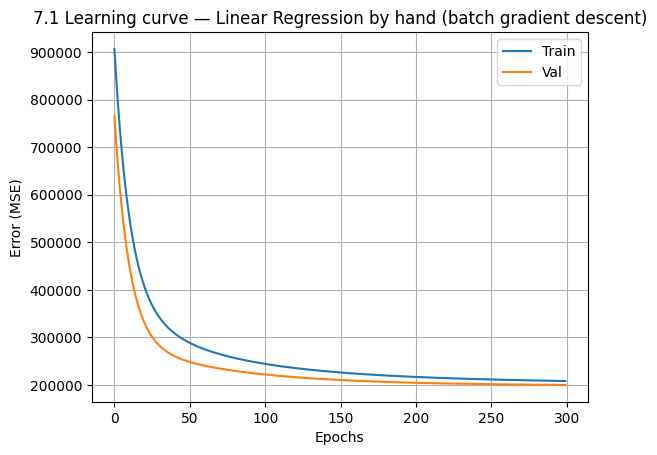

In [13]:
plt.plot(__errors__, label="Train")
plt.plot(__errors_val__, label="Val")
plt.xlabel("Epochs")
plt.ylabel("Error (MSE)")
plt.title("7.1 Learning curve — Linear Regression by hand (batch gradient descent)")
plt.legend()
plt.grid(True)
#plt.savefig('fig_71_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

MSE Val and Test.

In [14]:
def predict(samples, params):
	predict = []
	for i in range(len(samples)):
		predict.append(h(params, samples[i]))
	return predict
def mse_manual(y_real, y_pred):
	error_acum = 0
	for i in range(len(y_real)):
		error_acum = error_acum + (y_pred[i]-y_real[i])**2
	return error_acum/len(y_real)

y_pred_val = predict(X_val_s, params)
y_pred_test = predict(X_test_s, params)

print("MSE validation:", mse_manual(Y_val, y_pred_val))
print("MSE test:", mse_manual(Y_test, y_pred_test))

MSE validation: 200087.36914907492
MSE test: 255332.206787069


RMSE and MAE for test.

In [15]:
def rmse_manual(y_real, y_pred):
	return mse_manual(y_real, y_pred) ** 0.5

def mae_manual(y_real, y_pred):
	error_acum = 0
	for i in range(len(y_real)):
		error_acum = error_acum + abs(y_pred[i] - y_real[i])
	return error_acum/len(y_real)

print("RMSE test:", rmse_manual(Y_test, y_pred_test))
print("MAE  test:", mae_manual(Y_test, y_pred_test))

RMSE test: 505.30407359041646
MAE  test: 361.2470721550839


$$R^2 = 1 - \frac{\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^{m}(y^{(i)} - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}} \qquad \bar{y} = \frac{1}{m}\sum_{i=1}^{m} y^{(i)}$$

In [16]:
def r2_manual(y_real, y_pred):
	media = sum(y_real)/len(y_real)
	ss_res = 0
	ss_tot = 0
	for i in range(len(y_real)):
		ss_res = ss_res + (y_real[i] - y_pred[i])**2
		ss_tot = ss_tot + (y_real[i] - media)**2
	return 1 - (ss_res/ss_tot)

print("R² Validation:", r2_manual(Y_val, y_pred_val))
print("R² Test:", r2_manual(Y_test, y_pred_test))

R² Validation: 0.39958250070004175
R² Test: 0.3523458719065602


We create our graph comparing the real target vs the predicted.

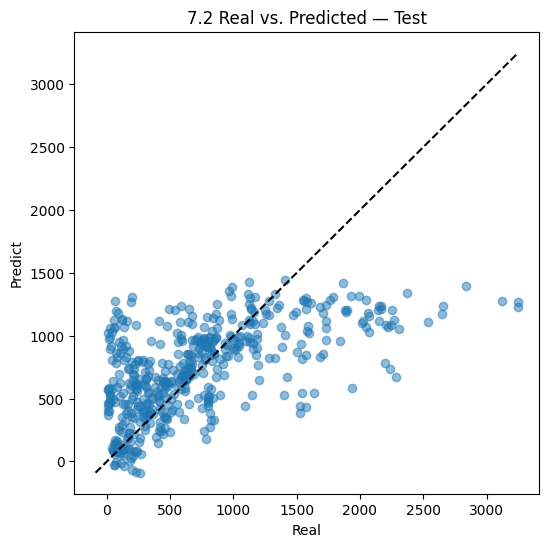

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred_test, alpha=0.5)
lims = [min(min(Y_test), min(y_pred_test)), max(max(Y_test), max(y_pred_test))]
plt.plot(lims, lims, 'k--')
plt.xlabel("Real")
plt.ylabel("Predict")
plt.title("7.2 Real vs. Predicted — Test")
#plt.savefig('fig_72_real_vs_pred.png', dpi=150, bbox_inches='tight'
plt.show()

The baseline always predict the training mean so we can compare it to.

In [18]:
mean_train = sum(Y_train)/len(Y_train)
baseline_test = [mean_train]*len(Y_test)

print("Training mean:", mean_train)
print("Baseline RMSE test:", rmse_manual(Y_test, baseline_test))
print("Baseline R2 test:", r2_manual(Y_test, baseline_test))

Training mean: 739.8381458966566
Baseline RMSE test: 628.2146468965017
Baseline R2 test: -0.0010451246918377066


Output for latex.

In [19]:
results_byhand = pd.DataFrame([
    {"Subset": "Validation",
     "MSE": mse_manual(Y_val, y_pred_val),
     "RMSE": rmse_manual(Y_val, y_pred_val),
     "MAE": mae_manual(Y_val, y_pred_val),
     "R2": r2_manual(Y_val, y_pred_val)},
    {"Subset": "Test",
     "MSE": mse_manual(Y_test, y_pred_test),
     "RMSE": rmse_manual(Y_test, y_pred_test),
     "MAE": mae_manual(Y_test, y_pred_test),
     "R2": r2_manual(Y_test, y_pred_test)},
]).set_index("Subset").round(4)

display(results_byhand)
print(results_byhand.to_latex(escape=True, float_format="%.4f"))

,MSE,RMSE,MAE,R2
Subset,,,,
Validation,200087.3691,447.3113,330.7427,0.3996
Test,255332.2068,505.3041,361.2471,0.3523


\begin{tabular}{lrrrr}
\toprule
 & MSE & RMSE & MAE & R2 \\
Subset &  &  &  &  \\
\midrule
Validation & 200087.3691 & 447.3113 & 330.7427 & 0.3996 \\
Test & 255332.2068 & 505.3041 & 361.2471 & 0.3523 \\
\bottomrule
\end{tabular}



Output for latex.

In [20]:
feature_names = pd.read_csv('X_train_seoul.csv').columns.tolist()

weights_table = pd.DataFrame({
    "Parameter": ["Bias"] + feature_names,
    "Weight": params
}).set_index("Parameter").round(4)

display(weights_table)
print(weights_table.to_latex(escape=True, float_format="%.4f"))

,Weight
Parameter,
Bias,739.8380
Hour,592.5202
Temperature(°C),436.9375
Humidity(%),-338.6270
Wind speed (m/s),88.6116
Visibility (10m),246.0339
Dew point temperature(°C),282.0122
Solar Radiation (MJ/m2),157.3056
Rainfall(mm),-35.7085


\begin{tabular}{lr}
\toprule
 & Weight \\
Parameter &  \\
\midrule
Bias & 739.8380 \\
Hour & 592.5202 \\
Temperature(°C) & 436.9375 \\
Humidity(\%) & -338.6270 \\
Wind speed (m/s) & 88.6116 \\
Visibility (10m) & 246.0339 \\
Dew point temperature(°C) & 282.0122 \\
Solar Radiation (MJ/m2) & 157.3056 \\
Rainfall(mm) & -35.7085 \\
Snowfall (cm) & -31.4478 \\
Seasons & 339.2028 \\
Holiday & -67.1860 \\
Weekend & -67.8890 \\
\bottomrule
\end{tabular}



Predictions under 0. Not a real output just error.

In [21]:
negatives = [p for p in y_pred_test if p < 0]
print(f"Negative predictions: {len(negatives)} of {len(y_pred_test)}")
print(f"Most negative: {min(y_pred_test):.2f}")

Negative predictions: 8 of 480
Most negative: -90.24
